In [36]:
import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image
import os

In [27]:
H = 400
W = 400
CONFIG = (H, W)

In [ ]:
def conver_image_to_matrice(image_path: str):
    # M = np.array(Image.open(image_path).convert('L'), dtype=float)
    # resized_M = M.re
    image = Image.open(image_path).convert('L')
    resized_image = image.resize(CONFIG, Image.Resampling.LANCZOS)
    M = np.array(resized_image, dtype=float)
    return M

In [42]:
def show_image(M):
    plt.figure(figsize=(12, 8))
    plt.imshow(M, cmap='gray')
    # plt.xlabel('None'

In [37]:
folder = 'dataset'

In [43]:
df = []
for file in os.listdir(folder):
    if file.lower().endswith('.jpg'):
        filepath = os.path.join(folder, file)
        M = conver_image_to_matrice(filepath)
        df.append(M)
        

In [ ]:
def cosine_simliarity(M1, M2):
    if M1 is None or M2 is None:
        return False
    M1 = M1.flatten()
    M2 = M2.flatten()
   
    
    M1n = M1 / np.linalg.norm(M1)
    M2n = M2 / np.linalg.norm(M2)
   
    return M1n @ M2n.T

In [82]:
df[0]

array([[18., 18., 18., ...,  1.,  1.,  1.],
       [18., 18., 18., ...,  1.,  1.,  1.],
       [18., 18., 18., ...,  1.,  1.,  1.],
       ...,
       [90., 90., 90., ..., 91., 91., 90.],
       [90., 90., 90., ..., 91., 91., 91.],
       [90., 90., 90., ..., 91., 91., 91.]], shape=(400, 400))

In [93]:
df[1].flatten

<function ndarray.flatten(order='C')>

In [117]:
cosine_simliarity(df[4], df[1])

np.float64(0.9470674641811623)

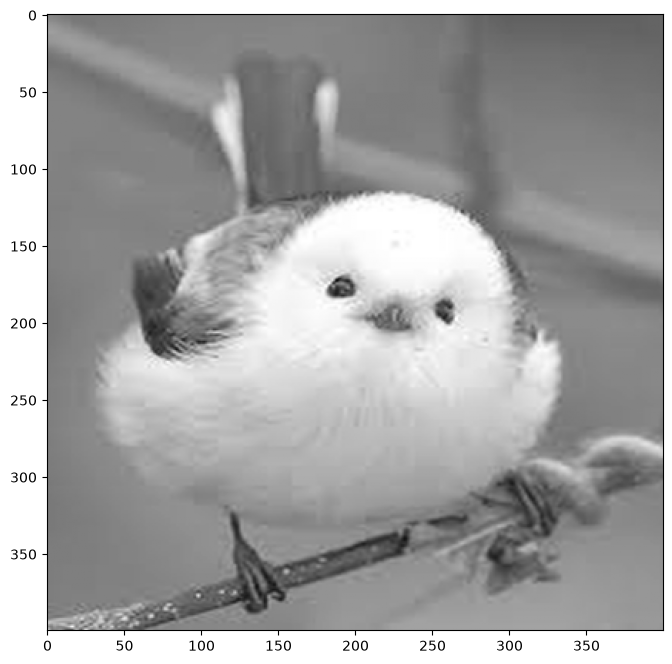

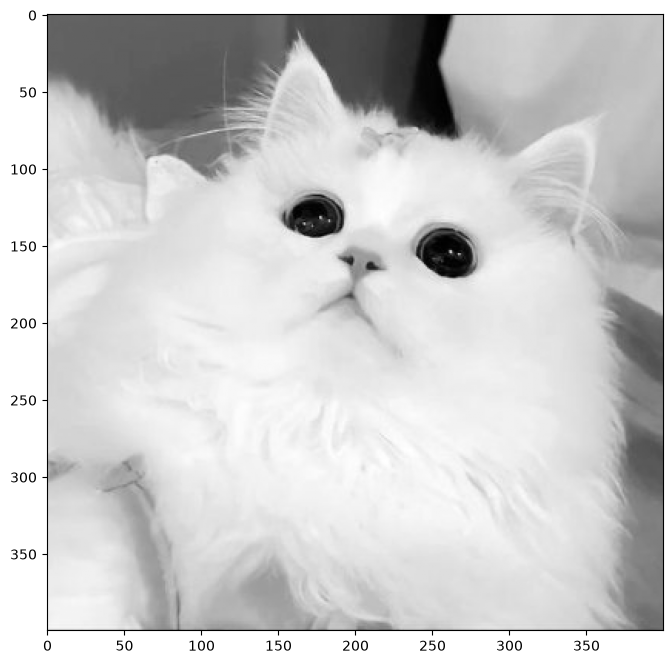

In [118]:
show_image(df[4])
show_image(df[1])

In [127]:
def search(query, top_k=3):
    if query is None or query.shape != CONFIG:
        return None, None
        
    mp = []

    for i, M in enumerate(df):
       
        score = cosine_simliarity(query, M) 
        mp.append((i, score))
        
    
    mp.sort(key=lambda x: x[1])
    if len(mp) <= top_k: return mp
    return mp[len(mp)-top_k:]

In [130]:
result = search(df[2])

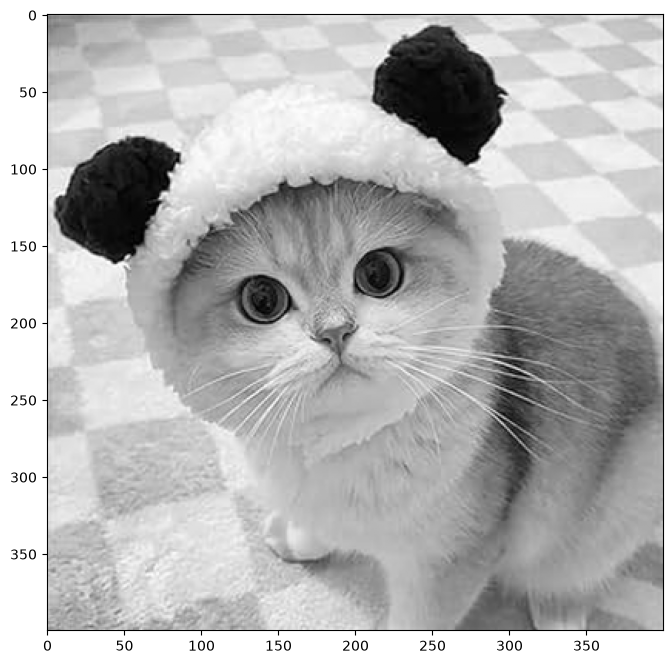

In [132]:
show_image(df[2])

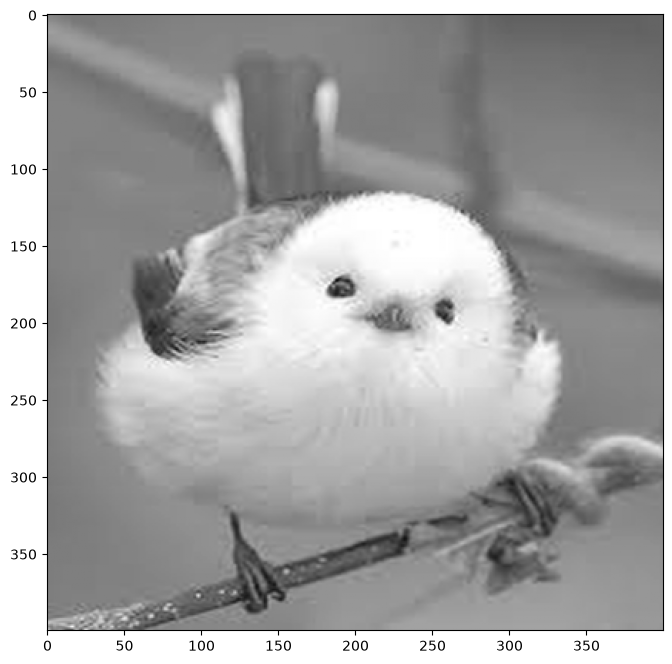

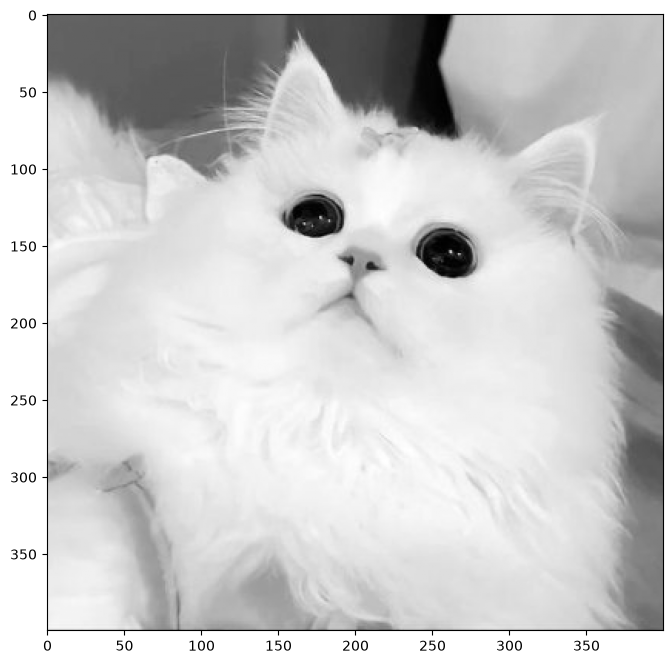

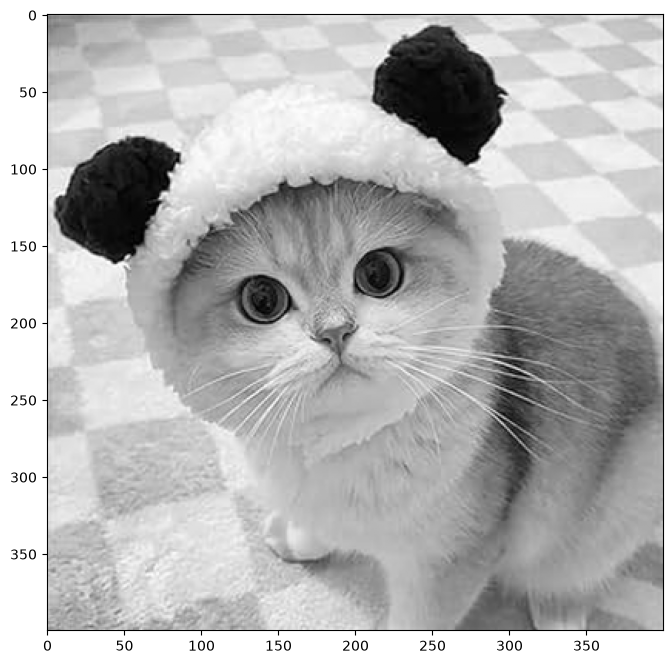

In [131]:
for _ in result:
    show_image(df[_[0]])

Bài 2


In [134]:
import numpy as np
import matplotlib.pyplot as plt

In [138]:
U, S, Vt = np.linalg.svd(df[0], full_matrices=False)

In [139]:
def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

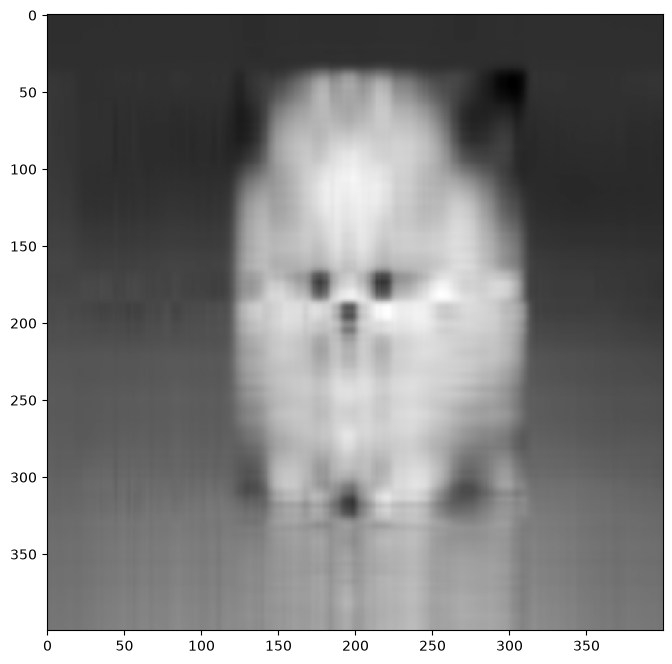

In [140]:
show_image(reconstruct(5))